# Deconvolve the origins of replication

October 22, 2024

## Goal:
Collect the origins of replication from the known Belsky list. Track the -1 and +1. Show that the change in NFR size is associated with G1 to S transition.

Possible ideas:
- How does this change with respect to efficiency and early/late replication timing?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.Figure3_Deconvolved_Origins import Figure4DeconvolvedOrigins

origins_analysis = Figure4DeconvolvedOrigins()

In [3]:
origins_analysis.load_origin()

In [4]:
origins_analysis.track_nfr()

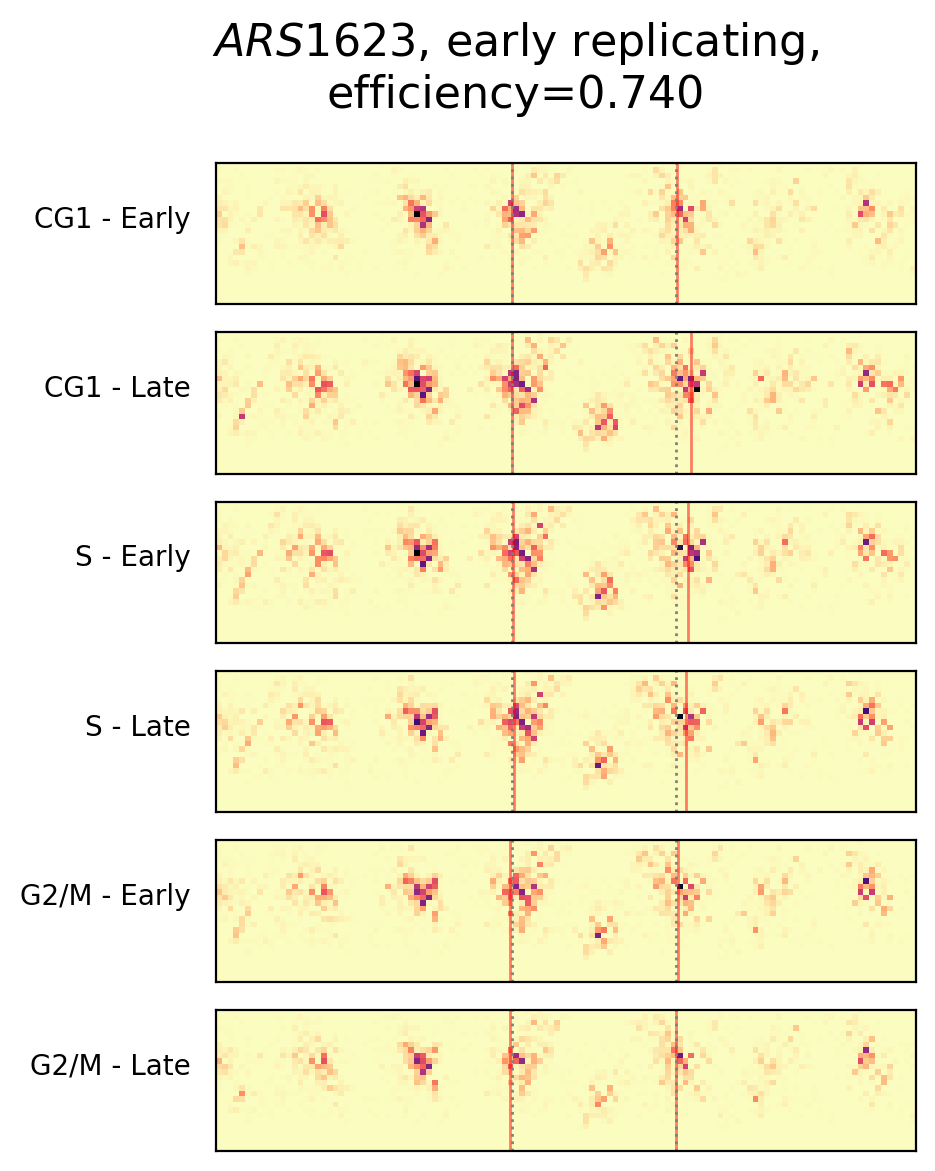

In [5]:
origins_analysis.plot_loaded_origin()

In [125]:
origins_analysis.compute_m1_p1_tracks()

00:00:41.863


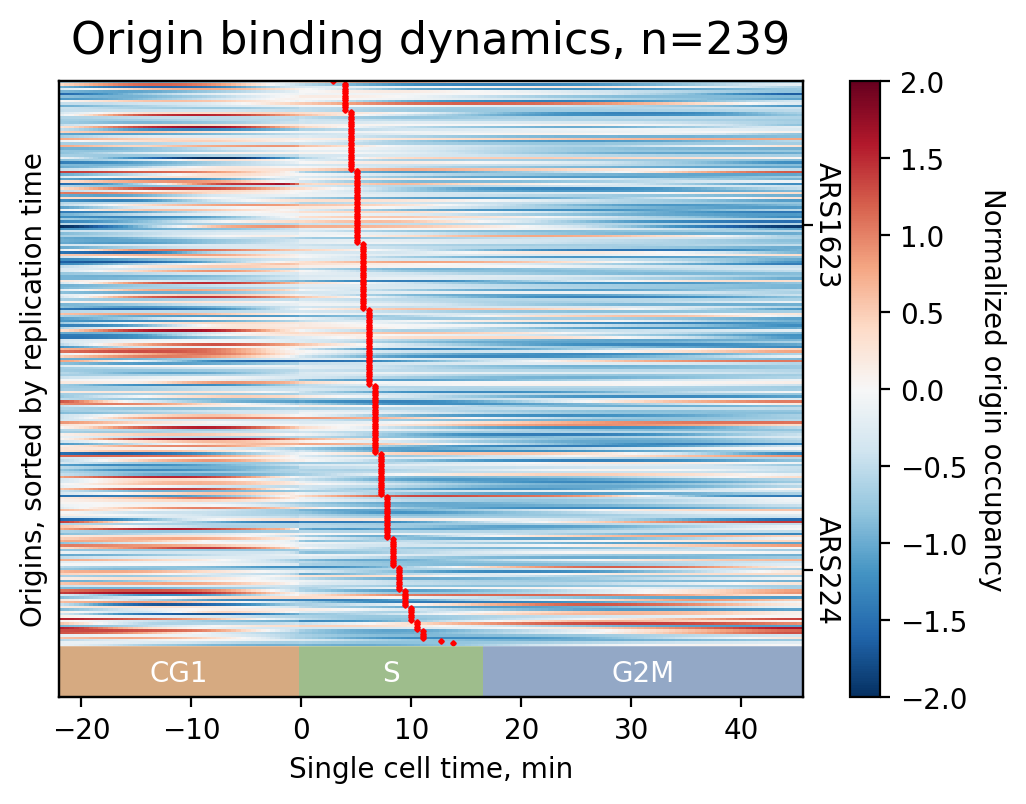

In [126]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

origins_analysis.plot_heatmap_occupancy(origins_analysis.all_occs_df, 
    annotate_oridbs=['oridb_809', 'oridb_77'])

save_figure_for_paper("output/figures/Origin_Deconvolution/Origin_occupancy_heatmap.png")

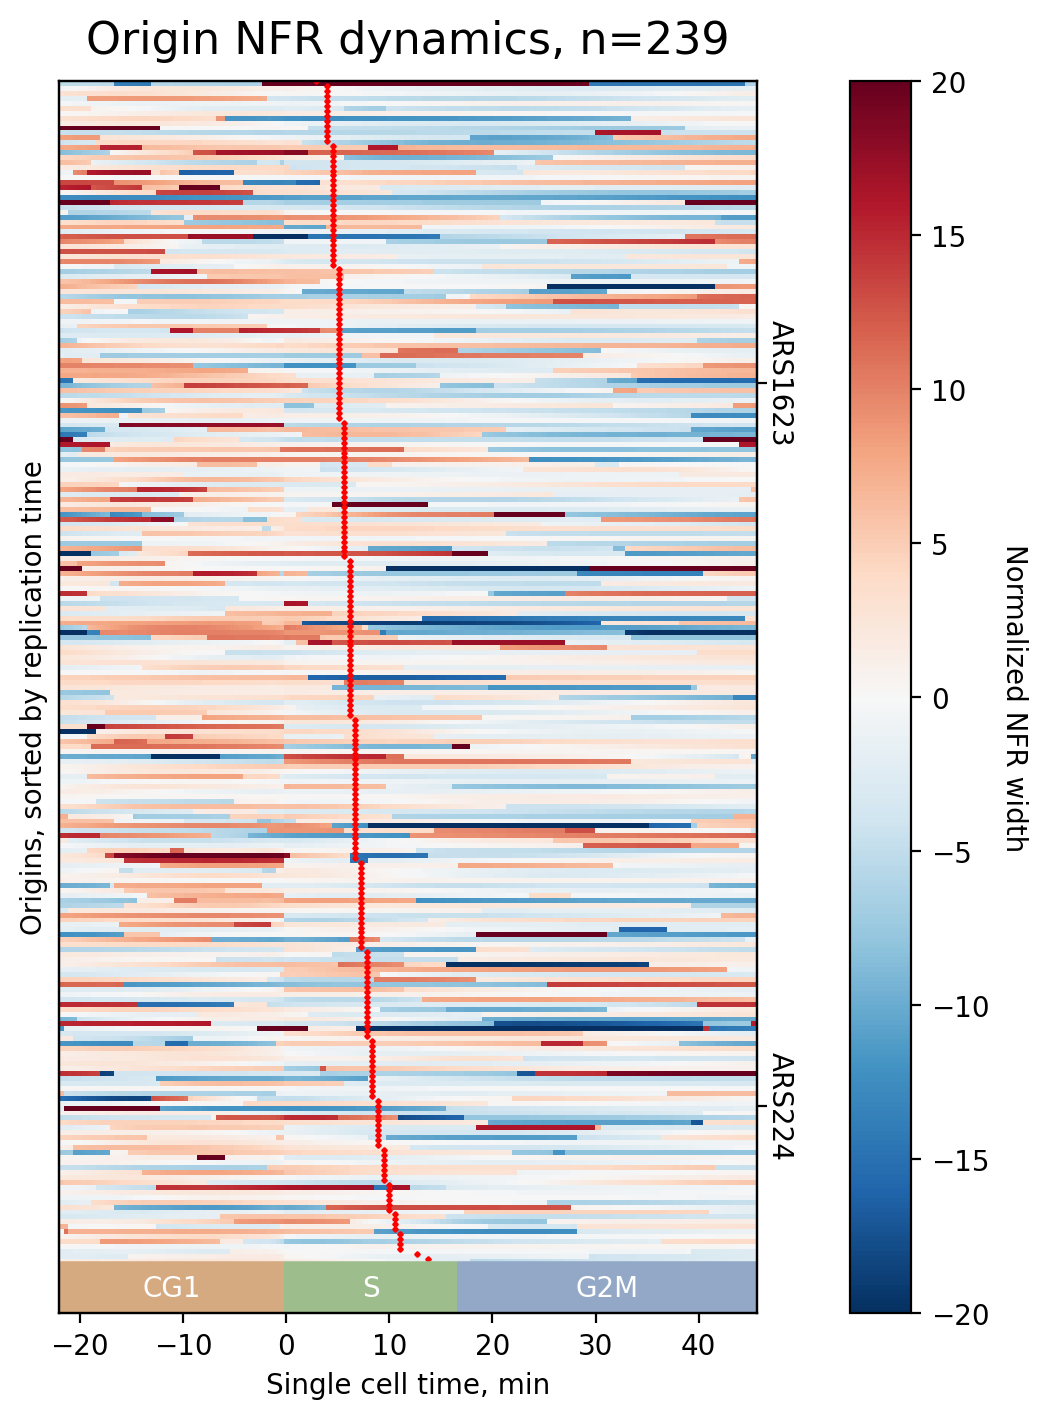

In [127]:
# Label the heatmap with the example origins that we are plotting
origins_analysis.plot_heatmap_nfr(origins_analysis.all_p1s_df, origins_analysis.all_m1s_df,
    annotate_oridbs=['oridb_809', 'oridb_77'])
save_figure_for_paper('output/figures/Origin_Deconvolution/Origin_NFR_heatmap.png')


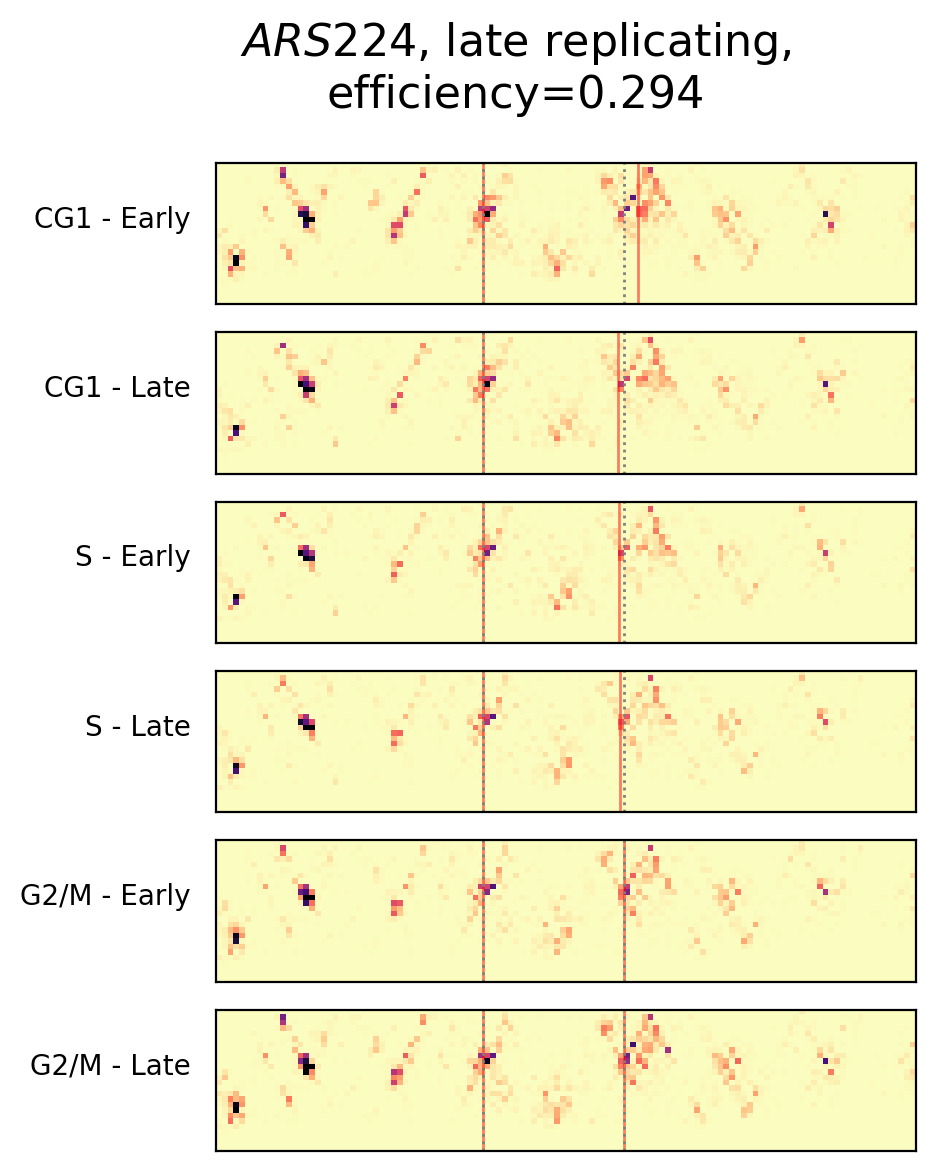

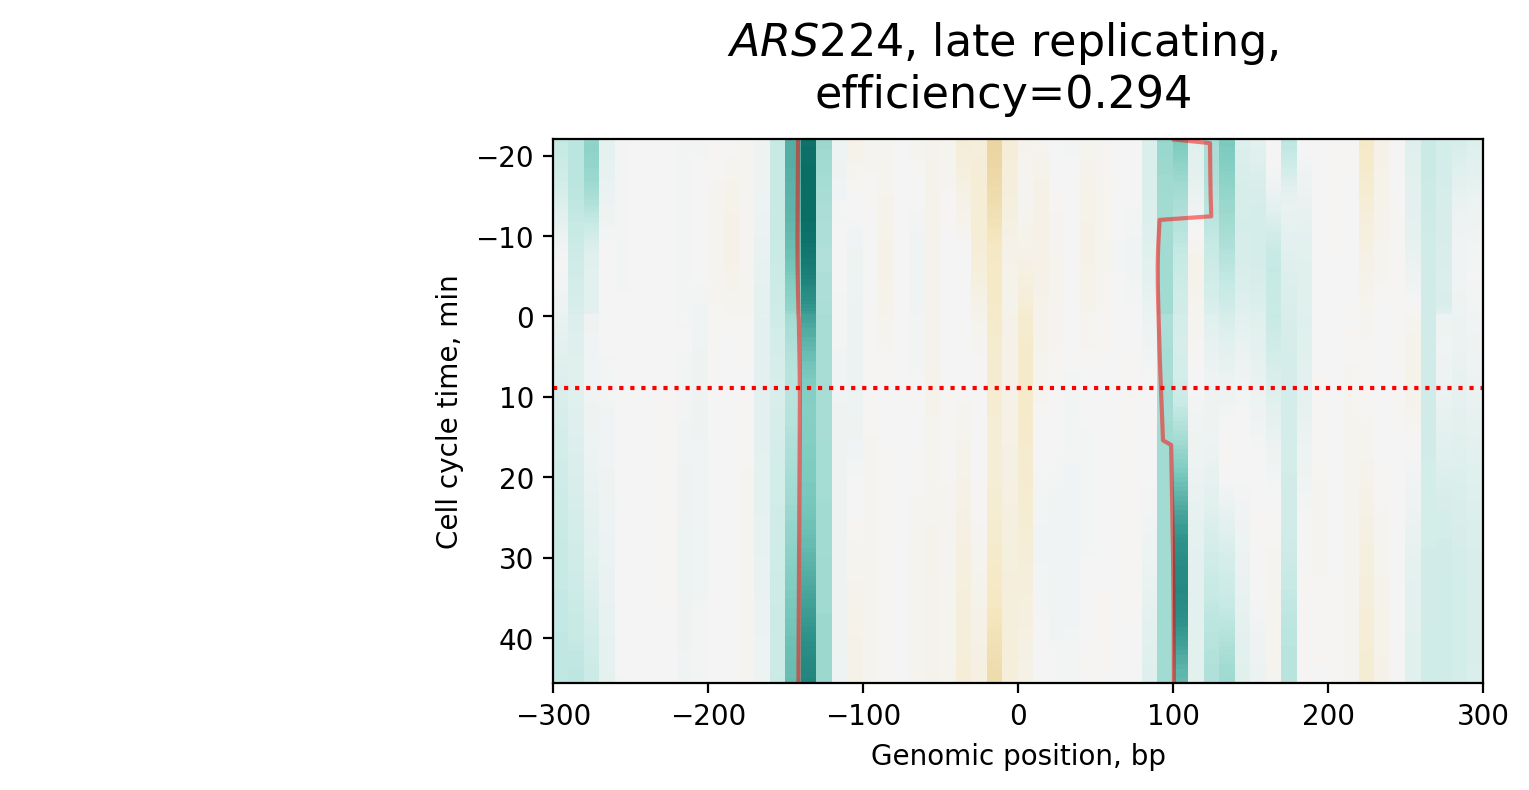

In [264]:
origin = origins_analysis.origins.loc['oridb_77']
origins_analysis.load_origin(origin)
origins_analysis.track_nfr()
origins_analysis.plot_loaded_origin()
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS224_Example_chromatin.png')

origins_analysis.plot_tracking_summary_hm()
plt.xlim(-300, 300)
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS224_Example_summary.png')


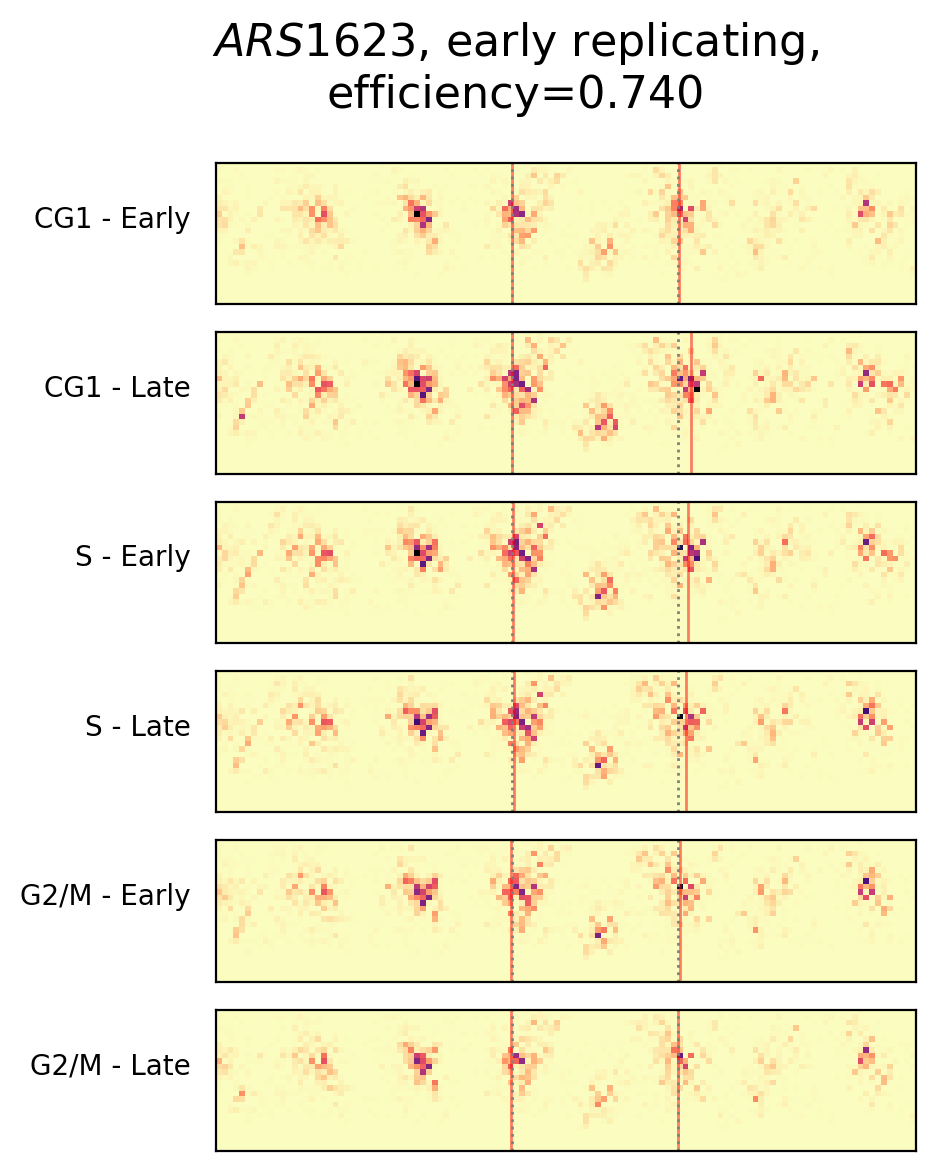

In [262]:
origins_analysis.load_origin()
origins_analysis.track_nfr()
origins_analysis.plot_loaded_origin()
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS1623_Example_chromatin.png')

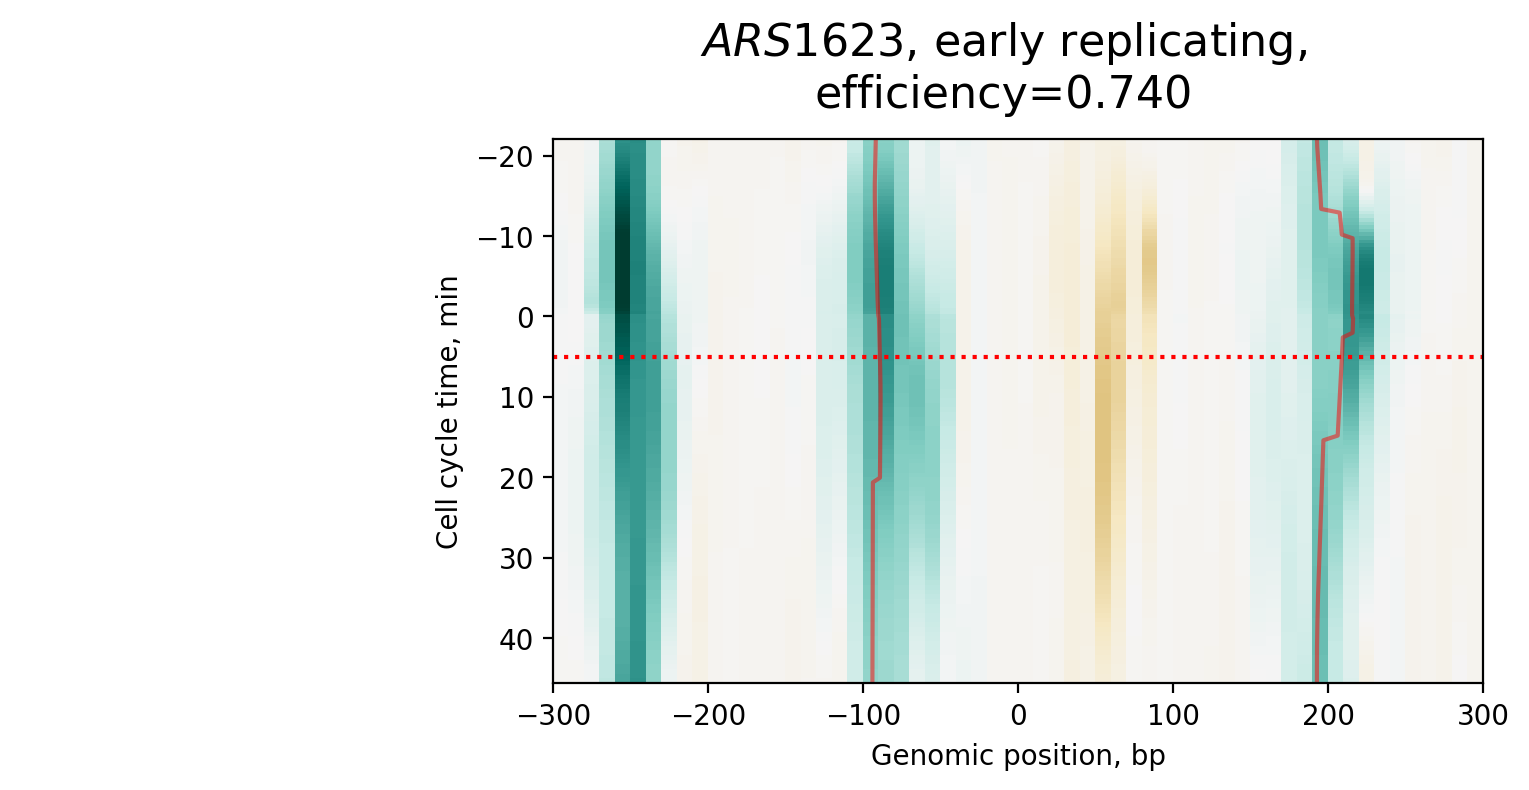

In [263]:
origins_analysis.plot_tracking_summary_hm()
plt.xlim(-300, 300)
save_figure_for_paper('output/figures/Origin_Deconvolution/ARS1623_Example_summary.png')

In [ ]:
# Attempt to explore Belsky's result of +1 and -1 nucleosome's shifting independently
# For the most part, was not able to reproduce a clear story, but it could be improved
# if we focused on filtering G1 vs G2 timepoints


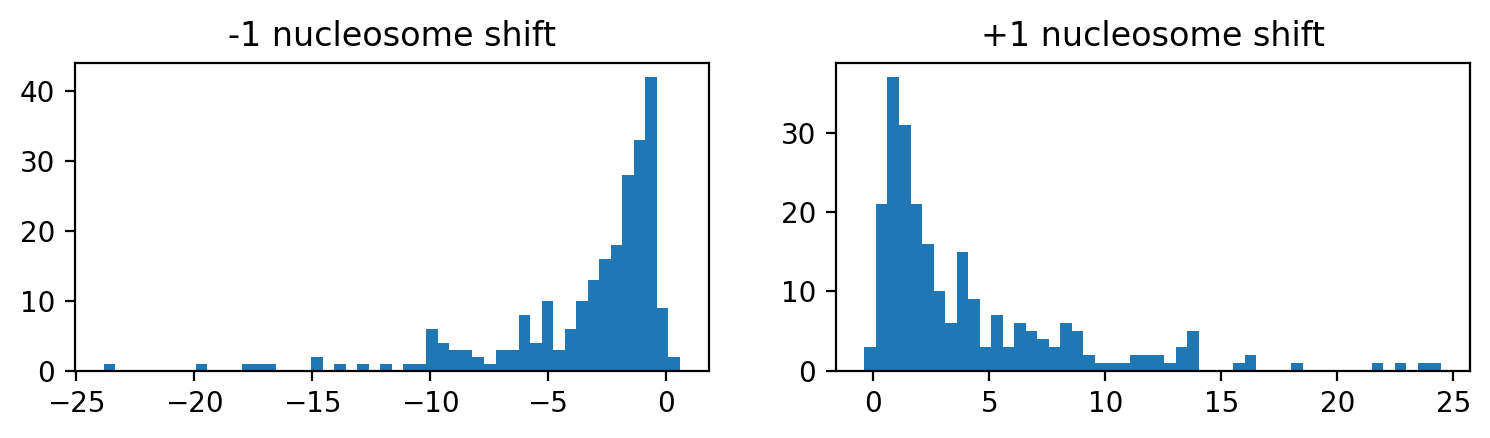

In [153]:
origins_analysis.filter_p1_m1_origins()

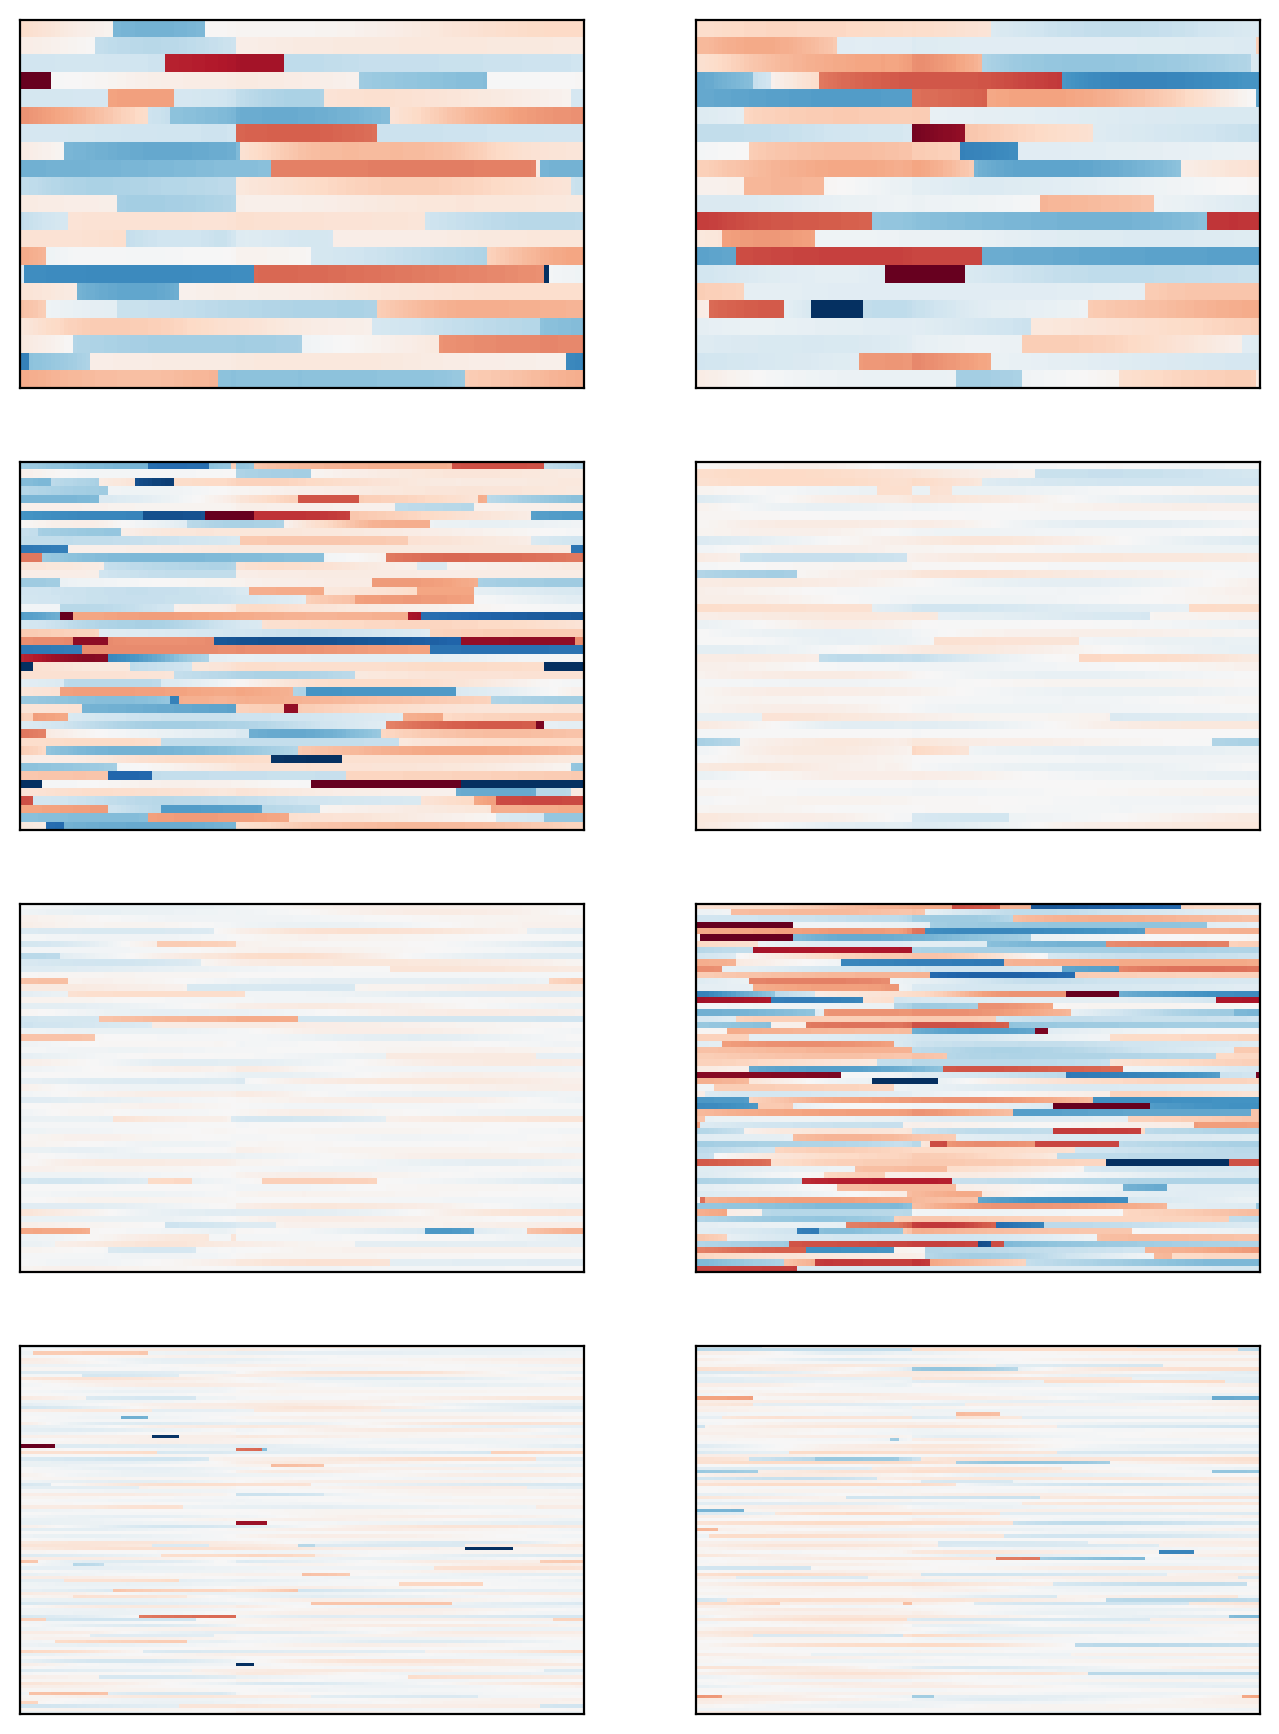

In [156]:
origins_analysis.plot_m1_p1_heatmap()

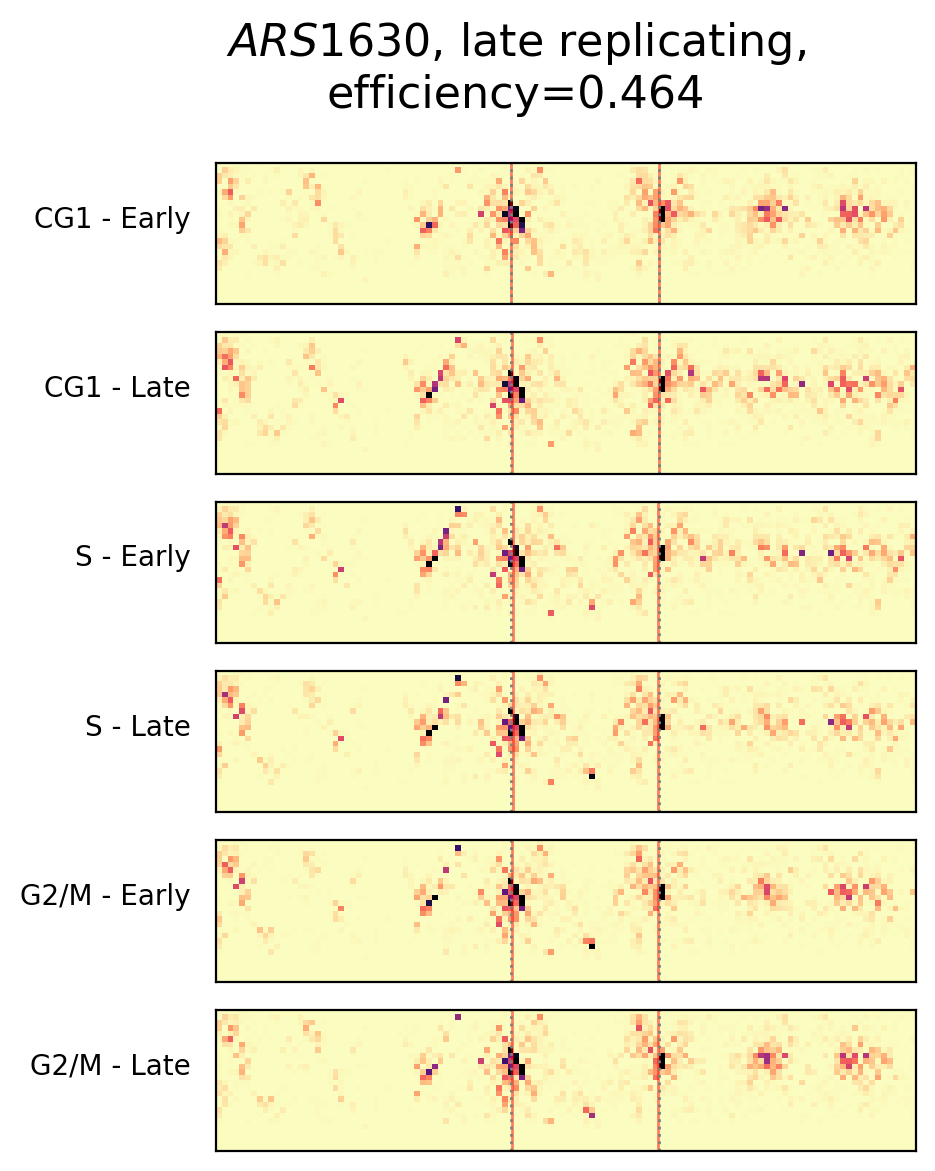

In [158]:
origins_analysis.plot_loaded_origin()

In [163]:
len(origins_analysis.orfs_m1_p1_both), len(origins_analysis.orfs_m1_p1_neither), \
len(origins_analysis.orfs_m1_p1_only_m1), len(origins_analysis.orfs_m1_p1_only_p1)

(21, 115, 44, 59)

In [245]:
from src.timer import Timer

def plot_nuc_ts_shift(self, orfs_selection):

    timer = Timer()

    all_occs_df = pd.DataFrame()
    all_m1s_df = pd.DataFrame()
    all_p1s_df = pd.DataFrame()

    avg_mnase_data = None


    for oridb, origin in self.origins.loc[orfs_selection].iterrows():

        self.load_origin(origin)

        if avg_mnase_data is None:
            avg_mnase_data = np.zeros_like(self.analysis.origin_mnase_data)

        avg_mnase_data += self.analysis.origin_mnase_data / len(orfs_selection)

    self.avg_mnase_data = avg_mnase_data
    
    from src.chromatin_metrics import fragment_lengths_definitions

    _, _, nuc_lens = fragment_lengths_definitions()

    dat = self.avg_mnase_data[t_indices, nuc_lens[0]//10:nuc_lens[1]//10, :].sum(axis=1).T
    n = dat.shape[1]
    colors = plt.get_cmap('Spectral')
    xs = np.arange(-self.padding, self.padding, 10)

    for i in range(0, n, 10):
        plt.plot(xs, dat[:, i], c=colors(i/n), alpha=1)
    plt.xlim(-300, 300)


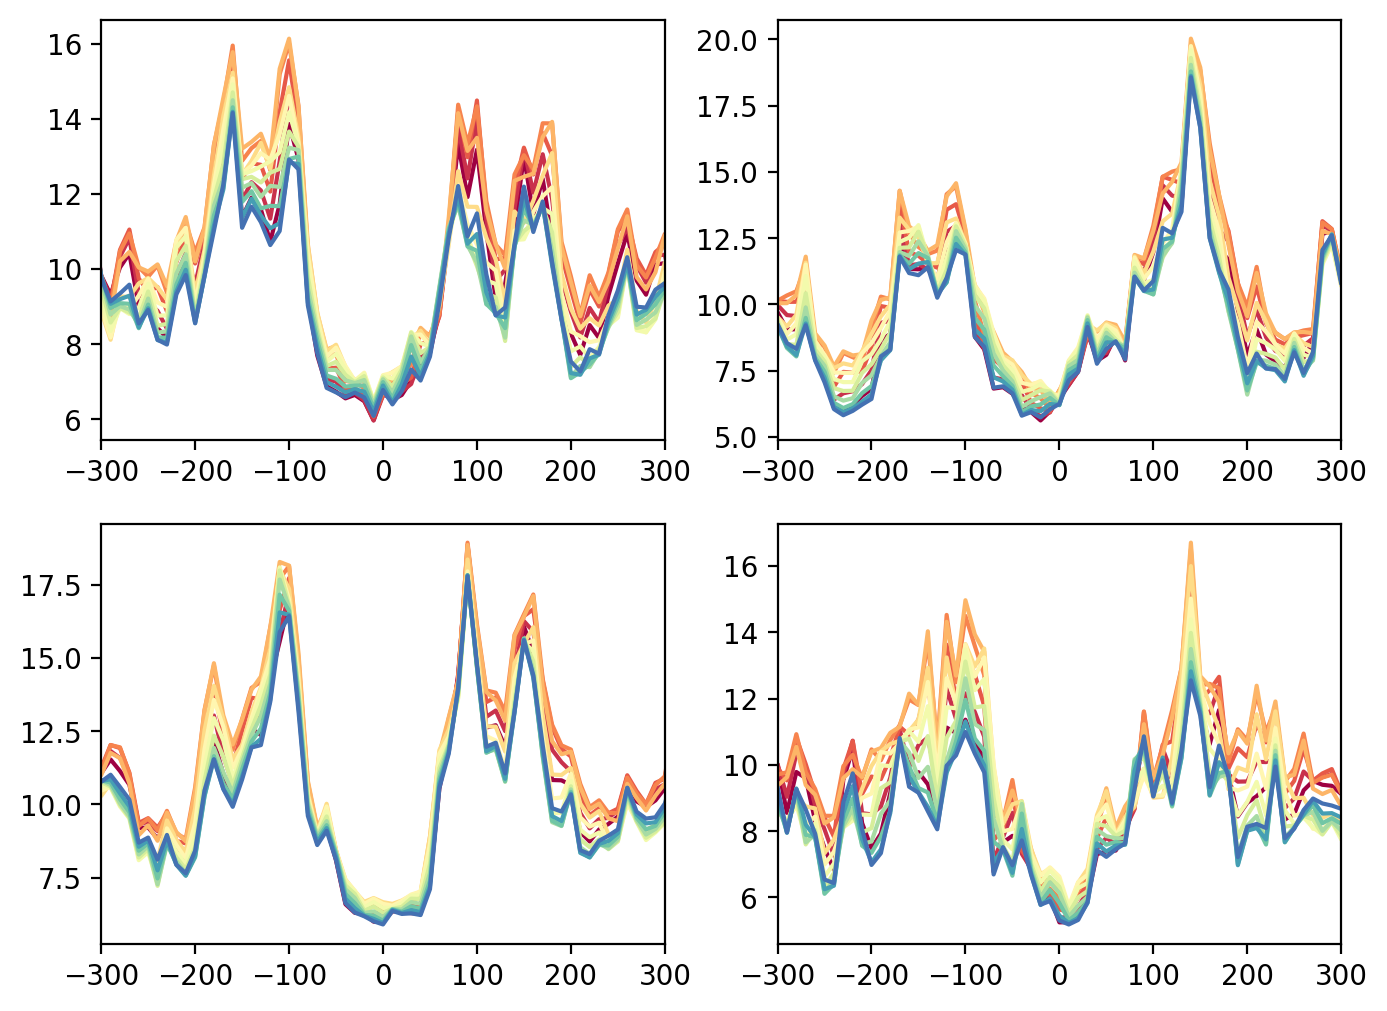

In [246]:
fig = plt.figure(figsize=(8, 6))

plt.subplot(2, 2, 1)
plot_nuc_ts_shift(origins_analysis, self.orfs_m1_p1_only_p1)

plt.subplot(2, 2, 2)
plot_nuc_ts_shift(origins_analysis, self.orfs_m1_p1_only_m1)

plt.subplot(2, 2, 3)
plot_nuc_ts_shift(origins_analysis, self.orfs_m1_p1_neither)

plt.subplot(2, 2, 4)
plot_nuc_ts_shift(origins_analysis, self.orfs_m1_p1_both)


In [256]:
plot_nuc_ts_shift(origins_analysis, self.orfs_m1_p1_only_p1)
plt.close()

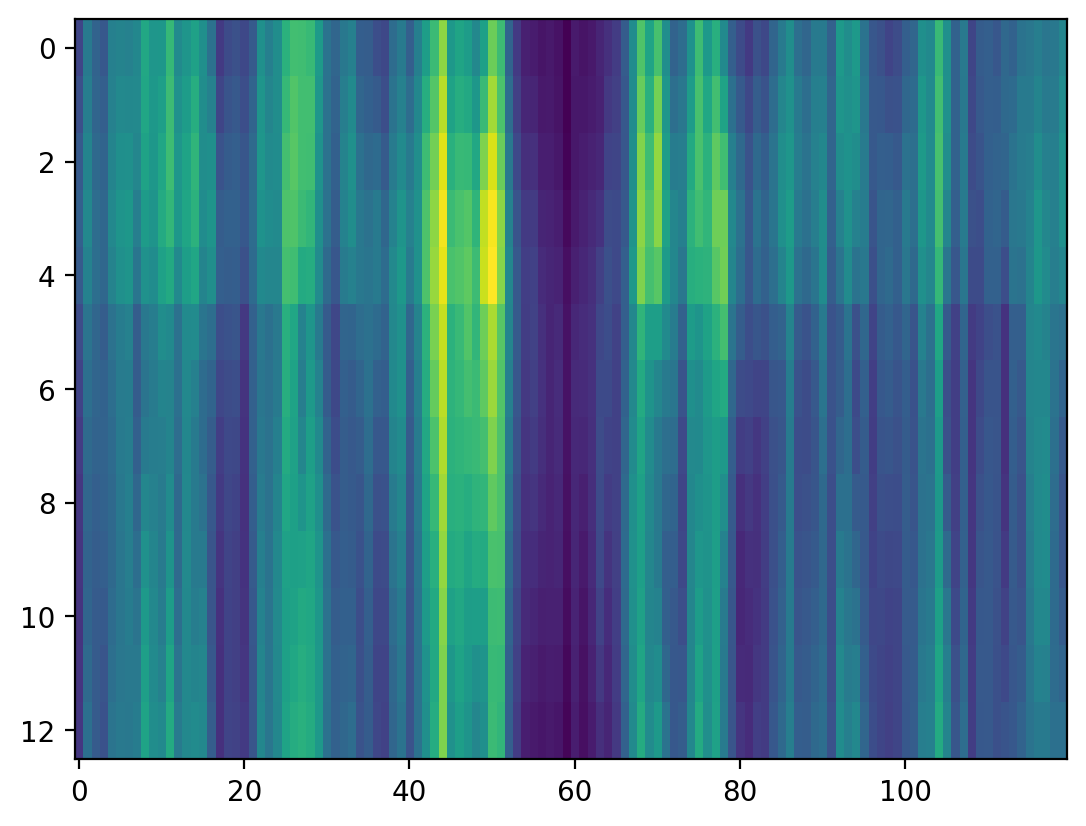

In [258]:
dat = self.avg_mnase_data[t_indices, nuc_lens[0]//10:nuc_lens[1]//10, :].sum(axis=1)
plt.imshow(dat[np.arange(0, dat.shape[0], 10)], aspect='auto')

0

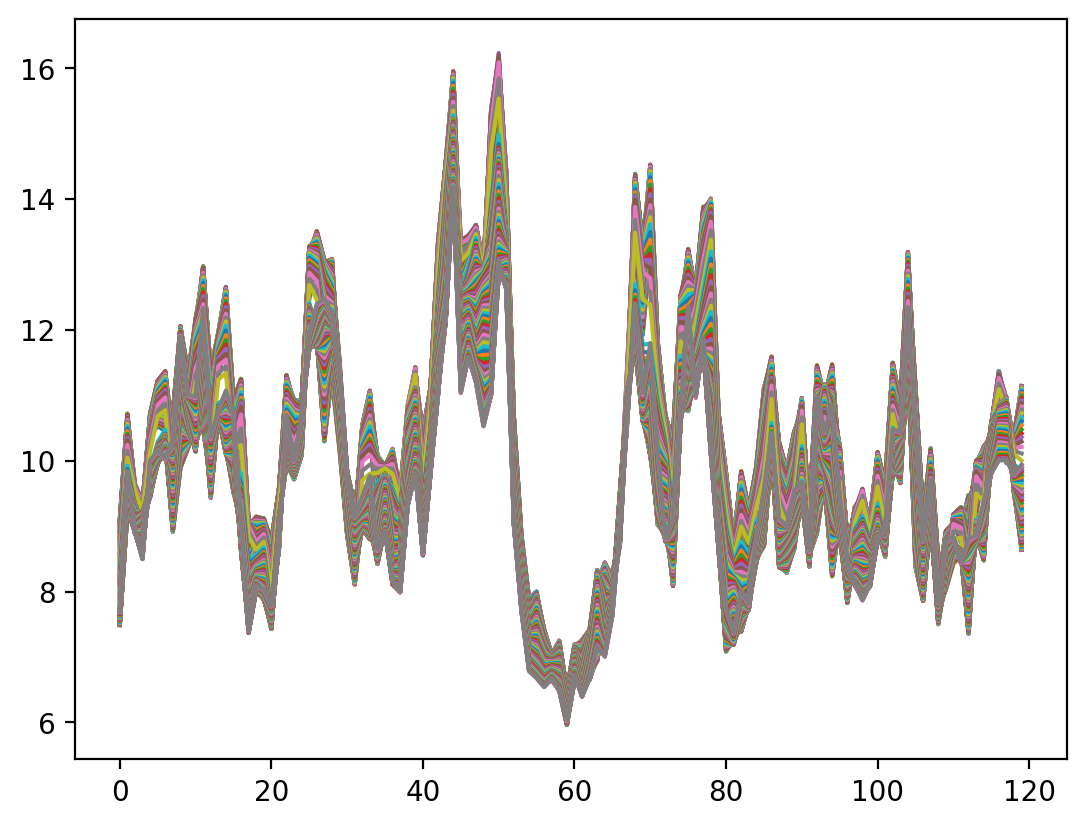

In [254]:
dat.shape
plt.plot(dat.T)
0

In [ ]:
# It isn't easy to show the G1/G2 plots with this data set 
# because the +1 nucleosomes are not lined up.

# Regroup, this may be more work than it needs to be at this point....
# Reflect a little on how much effort this may need, and what we are trying to convey.